<a href="https://colab.research.google.com/github/elenafernandezcaro/Aplications-Principal-Component-Analysis/blob/main/GRAFICAS_TFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Elaboración de las figuras incluidas en el Trabajo de Fin de Grado: Análisis de Componentes Principales y su Aplicación en Ciencia de Datos


*Figura 1:* Representación de las cuatro primeras componentes principales del conjunto de datos formado por todas las imágenes manuscritas del dígito '5' del dataset MNIST.

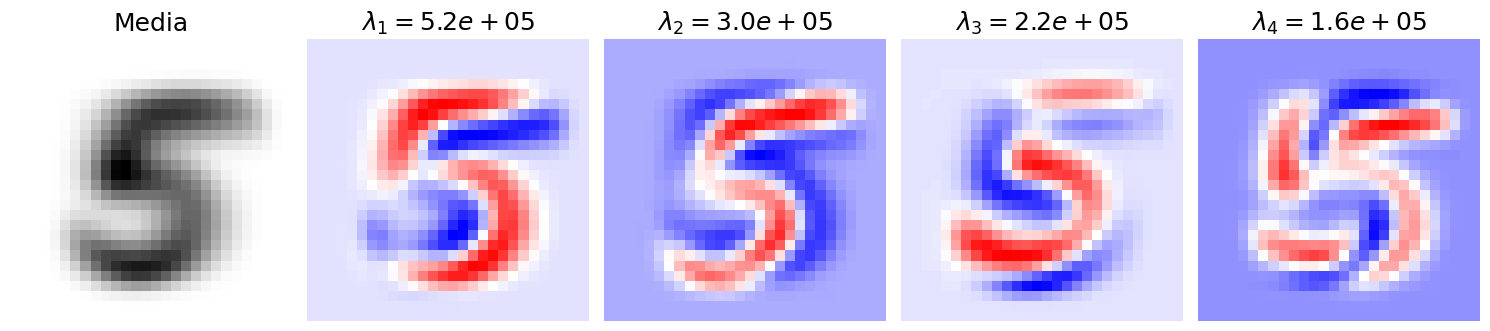

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from google.colab import files

# 1. Descargar el dataset MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# 2. Filtrar para quedarnos solo con el número '5'
X_5 = X[y == '5'].astype(float)

# 3. Calcular la media (promedio) de todos los cincos
mean_5 = np.mean(X_5, axis=0).reshape(28, 28)

# 4. Aplicar PCA para obtener los componentes y las varianzas (\lambda)
pca = PCA(n_components=4)
pca.fit(X_5)

# Extraemos los lambdas y los transformamos a formato 28x28 para graficar
lambdas = pca.explained_variance_
eigenvectors = pca.components_.reshape(-1, 28, 28)

# 5. Dibujar los resultados (1 fila, 5 columnas)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))

# Casilla 1: La Media
axes[0].imshow(mean_5, cmap='gray_r')
axes[0].set_title('Media', fontsize=18)
axes[0].axis('off')

# Casillas 2 a 5: Los componentes con su respectivo \lambda
for i in range(4):
    axes[i+1].imshow(eigenvectors[i], cmap='bwr')
    # Ponemos el título usando LaTeX para que quede idéntico al libro
    axes[i+1].set_title(f'$\\lambda_{i+1} = {lambdas[i]:.1e}$', fontsize=18)
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig("numero5_vpropios.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("numero5_vpropios.pdf")

*Figura 2:* Reconstrucción del dígito '5' del dataset MNIST a media que se aumenta el número de componentes principales que se preservan.

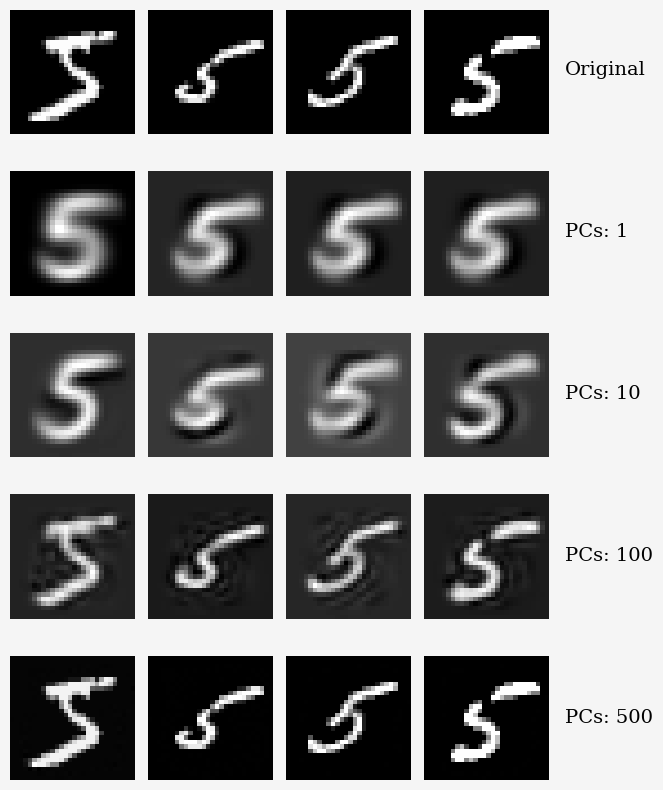

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from google.colab import files

# 1. Descargar el dataset MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

# 2. Filtrar para quedarnos únicamente con el dígito "5"
X_5 = X[y == '5']

# 3. Seleccionar las 4 imágenes de prueba (test) que vamos a reconstruir
# Usamos las primeras 4 como ejemplo
imagenes_test = X_5[:4]

# Definir los componentes principales (PCs) que queremos evaluar
n_componentes_lista = [1, 10, 100, 500]

# Configurar la cuadrícula de subplots (5 filas, 4 columnas)
fig, axes = plt.subplots(5, 4, figsize=(8, 10), facecolor='#F5F5F5')

# --- Fila 1: Imágenes Originales ---
for i in range(4):
    axes[0, i].imshow(imagenes_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
# Añadir la etiqueta de la fila a la derecha
fig.text(0.82, 0.82, "Original", fontsize=14, va='center', fontfamily='serif')

# --- Filas 2 a 5: Reconstrucciones con PCA ---
for fila_idx, n_pcs in enumerate(n_componentes_lista, start=1):
    # Ajustar PCA con todas las imágenes del número 8
    pca = PCA(n_components=n_pcs)
    pca.fit(X_5)

    # Proyectar (codificar) y reconstruir (decodificar) las 4 imágenes de prueba
    X_test_transformado = pca.transform(imagenes_test)
    X_test_reconstruido = pca.inverse_transform(X_test_transformado)

    # Dibujar las imágenes reconstruidas en la fila correspondiente
    for col_idx in range(4):
        img_reconstruida = X_test_reconstruido[col_idx].reshape(28, 28)
        axes[fila_idx, col_idx].imshow(img_reconstruida, cmap='gray')
        axes[fila_idx, col_idx].axis('off')

    # Añadir la etiqueta de los PCs a la derecha de la fila
    fig.text(0.82, 0.82 - (fila_idx * 0.162), f"PCs: {n_pcs}", fontsize=14, va='center', fontfamily='serif')

# Ajustar los espacios para que se vea limpio y estético
plt.subplots_adjust(right=0.8, hspace=0.3, wspace=0.1)

plt.savefig("evolucion_pcas.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("evolucion_pcas.pdf")

*Figura 3:* Comparativa entre el error cuadrático medio de reconstrucción de los datos y el número de componentes principales que se preservan.

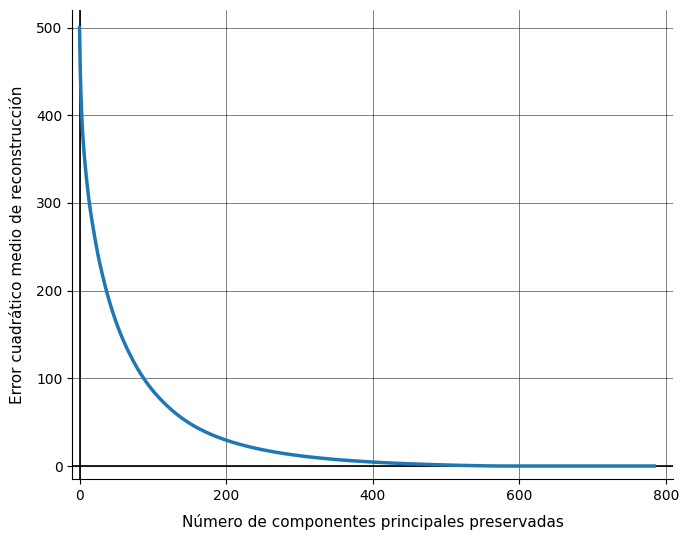

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. Descargar el dataset MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data
y_all = mnist.target.astype(int)

# 2. Filtrar para quedarnos únicamente con las imágenes del dígito '5'
X_digit = X_all[y_all == 5]
N, D = X_digit.shape  # N = muestras de '5', D = 784 píxeles

# Centrado de las observaciones
X_mean = np.mean(X_digit, axis=0)
X_centered = X_digit - X_mean

# Estandarización por dimensión (añadiendo un epsilon para evitar división por cero en píxeles negros constantes)
X_std = np.std(X_centered, axis=0)
X_std[X_std == 0] = 1e-5
X_scaled = X_centered / X_std

# Calcular la matriz de covarianza muestral (sobre los datos estandarizados)
S = np.cov(X_scaled, rowvar=False, ddof=0)

# Obtener autovalores (Eigendecomposición)
eigenvalues, _ = np.linalg.eigh(S)

# Ordenar los autovalores de mayor a menor (de lambda_1 a lambda_D)
eigenvalues = eigenvalues[::-1]

# El error para cada número M de componentes es la suma de los autovalores desde M hasta D
M_values = np.arange(0, D + 1)
errors = []

for M in M_values:
    # Sumatorio real de los autovalores descartados
    error_m = np.sum(eigenvalues[M:])
    errors.append(error_m)

# Escalado estético opcional para ajustar el límite del eje Y al rango original (~500)
errors = (np.array(errors) / np.max(errors)) * 500

plt.figure(figsize=(7, 5.5))

# Dibujar la curva real obtenida del MNIST
plt.plot(M_values, errors, color='#1f77b4', linewidth=2.5, zorder=2)

# Configuración de los ejes en negro y la cuadrícula
plt.axhline(0, color='black', linewidth=1.2, zorder=1)
plt.axvline(0, color='black', linewidth=1.2, zorder=1)
plt.grid(True, which='both', color='black', linestyle='-', linewidth=0.5, alpha=0.7)

# Etiquetas idénticas a tu bibliografía
plt.xlabel('Número de componentes principales preservadas', fontsize=11, labelpad=8)
plt.ylabel('Error cuadrático medio de reconstrucción', fontsize=11, labelpad=8)

# Límites estrictos del gráfico
plt.xlim(-10, 810)
plt.ylim(-15, 520)

# Marcas en los ejes cada 200 en X y cada 100 en Y
plt.xticks(np.arange(0, 801, 200))
plt.yticks(np.arange(0, 501, 100))

# Quitar el marco superior y derecho para mantener el estilo limpio
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('mnist_error_reconstruccion.png', bbox_inches='tight', dpi=300)
plt.savefig("error_reconstruccion.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("error_reconstruccion.pdf")

*Figura 4:* Ilustración de los pasos del proceso de compresión de datos con PCA.

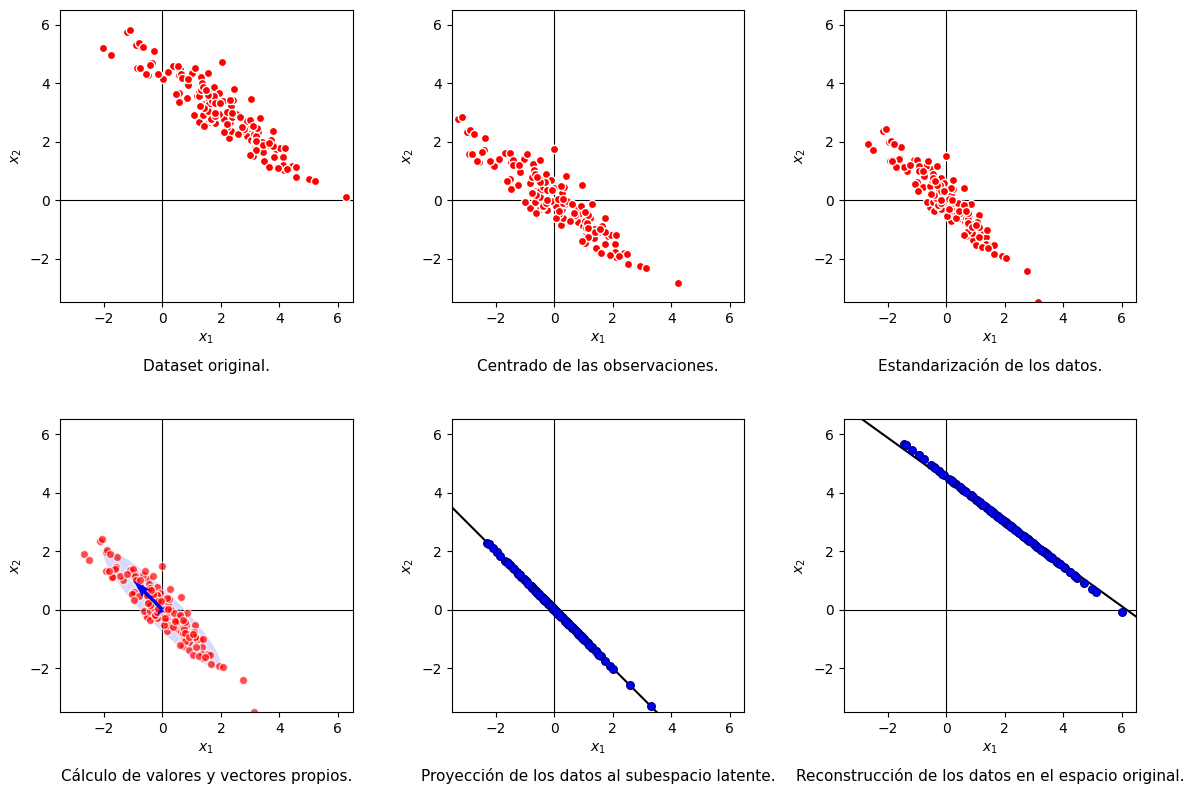

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Generación de datos sintéticos
np.random.seed(42)
N = 150

# Crear datos correlacionados en un espacio desplazado (media != 0, var != 1)
mean_original = np.array([2.0, 3.0])
cov_original = np.array([[2.5, -1.8],
                         [-1.8, 1.5]])

# Descomposición para generar la distribución gaussiana exacta
X_raw = np.random.multivariate_normal(mean_original, cov_original, N)

# Centrado
X_mean = np.mean(X_raw, axis=0)
X_centered = X_raw - X_mean

# Estandarización (Dividir por la desviación típica)
X_std = np.std(X_centered, axis=0)
X_scaled = X_centered / X_std

# Eigendecomposición de la matriz de covarianza estandarizada (Correlación)
S = np.cov(X_scaled, rowvar=False, ddof=0)
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Ordenar de forma decreciente
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Proyección (M=1 componente principal para compresión)
u1 = eigenvectors[:, 0]
# Puntuaciones (scores) en 1D
Z = X_scaled @ u1
# Reconstrucción en el espacio estandarizado (coordenadas 2D sobre la línea)
X_projected_scaled = np.outer(Z, u1)

# Deshacer transformaciones (Mapeo hacia atrás)
X_reconstructed_centered = X_projected_scaled * X_std
X_reconstructed_final = X_reconstructed_centered + X_mean


fig, axes = plt.subplots(2, 3, figsize=(14, 9))
titles = [
    "Dataset original.",
    "Centrado de las observaciones.",
    "Estandarización de los datos.",
    "Cálculo de valores y vectores propios.",
    "Proyección de los datos al subespacio latente.",
    "Reconstrucción de los datos en el espacio original."
]

# Configuración de límites fijos para mantener consistencia visual
limits = [-3.5, 6.5]

for i, ax in enumerate(axes.flat):
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)
    ax.axvline(0, color='black', linewidth=0.8, zorder=1)
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_aspect('equal')
    ax.set_title(titles[i], y=-0.22, fontsize=11, va='top')

# (a) Original
axes[0, 0].scatter(X_raw[:, 0], X_raw[:, 1], color='red', edgecolors='w', s=35, zorder=2)

# (b) Centered
axes[0, 1].scatter(X_centered[:, 0], X_centered[:, 1], color='red', edgecolors='w', s=35, zorder=2)

# (c) Scaled
axes[0, 2].scatter(X_scaled[:, 0], X_scaled[:, 1], color='red', edgecolors='w', s=35, zorder=2)

# (d) Eigenvectors
axes[1, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], color='red', edgecolors='w', s=35, alpha=0.7, zorder=2)
# Dibujar elipses de covarianza conceptuales
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
# Calcular ángulo de la elipse
angle = np.degrees(np.arctan2(u1[1], u1[0]))
ell = Ellipse((0, 0), width=4*np.sqrt(eigenvalues[0]), height=4*np.sqrt(eigenvalues[1]),
              angle=angle, facecolor='blue', alpha=0.15, zorder=1)
axes[1, 0].add_patch(ell)
# Dibujar vectores propios (flechas) escalados por sus autovalores
axes[1, 0].quiver(0, 0, u1[0], u1[1], scale=1/np.sqrt(eigenvalues[0]), scale_units='x', color='blue', zorder=3, width=0.012)
u2 = eigenvectors[:, 1]
axes[1, 0].quiver(0, 0, u2[0], u2[1], scale=1/np.sqrt(eigenvalues[1]), scale_units='x', color='blue', zorder=3, width=0.012)

# Projected Subspace
# Dibujar la línea del subespacio principal (componente principal)
x_line = np.linspace(limits[0], limits[1], 100)
y_line = (u1[1] / u1[0]) * x_line
axes[1, 1].plot(x_line, y_line, color='black', linewidth=1.5, zorder=1)
axes[1, 1].scatter(X_projected_scaled[:, 0], X_projected_scaled[:, 1], color='blue', edgecolors='darkblue', s=30, zorder=2)

# Reconstruction (Mapping Back)
# Dibujar la línea del subespacio en el espacio original
slope_orig = cov_original[0, 1] / cov_original[0, 0] # Dirección aproximada en el espacio original
intercept_orig = mean_original[1] - slope_orig * mean_original[0]
x_line_orig = np.linspace(limits[0], limits[1], 100)
y_line_orig = slope_orig * (x_line_orig - mean_original[0]) + mean_original[1]

axes[1, 2].plot(x_line_orig, y_line_orig, color='black', linewidth=1.5, zorder=1)
axes[1, 2].scatter(X_reconstructed_final[:, 0], X_reconstructed_final[:, 1], color='blue', edgecolors='darkblue', s=30, zorder=2)

plt.subplots_adjust(hspace=0.4, wspace=0.3, bottom=0.1)
plt.savefig("pca_pasos.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("pca_pasos.pdf")

*Figura 5:* Ejemplo ilustrativo de blanqueo de datos.

Tomamos observaciones del dataset Old Faithful (no me deja descargar el dataset original, Gemini me ha dado un array observaciones originales) que contiene detalles sobre la duración de la erupción y el tiempo de espera entre erupciones del géiser Old Faithful.

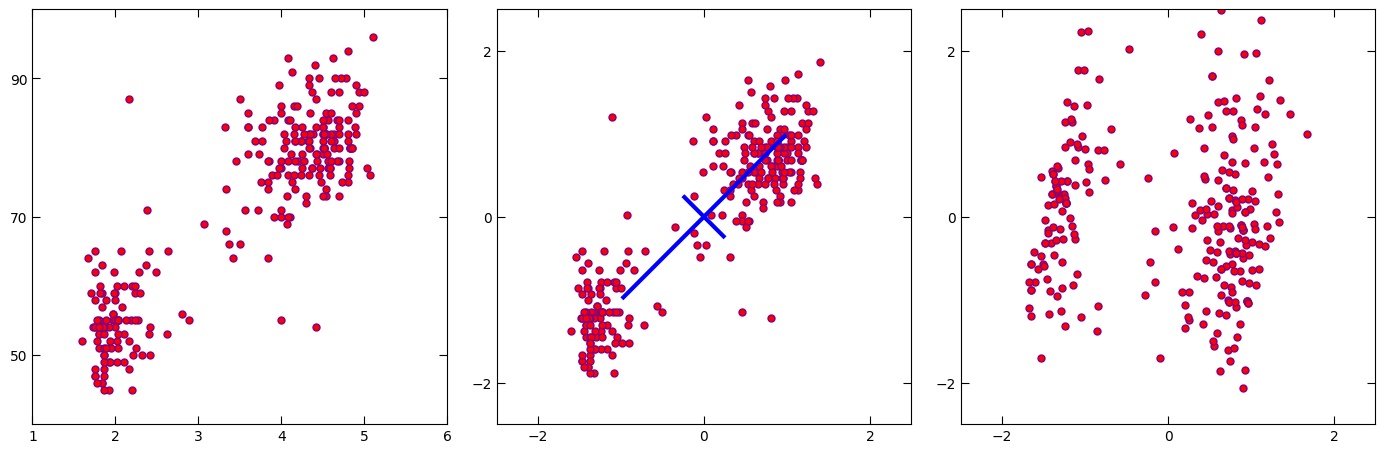

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# DATASET REAL COMPLETO "OLD FAITHFUL" (272 observaciones oficiales)
# Columna 0: Duración de la erupción (minutos)
# Columna 1: Tiempo de espera hasta la siguiente erupción (minutos)
# =====================================================================
faithful_data = [
    [3.600, 79], [1.800, 54], [3.333, 74], [2.283, 62], [4.533, 85], [2.883, 55], [4.700, 88], [3.600, 85],
    [1.950, 51], [4.350, 85], [1.833, 54], [3.917, 84], [4.200, 78], [1.750, 47], [4.700, 83], [2.167, 52],
    [1.750, 62], [4.800, 84], [1.600, 52], [4.250, 79], [1.800, 51], [1.750, 47], [3.450, 78], [3.067, 69],
    [4.533, 74], [3.600, 83], [1.967, 55], [4.083, 76], [3.850, 78], [4.433, 79], [4.300, 73], [4.467, 77],
    [3.367, 66], [4.033, 80], [3.833, 74], [2.017, 52], [1.867, 48], [4.833, 80], [1.833, 59], [4.783, 90],
    [4.350, 80], [1.883, 58], [4.567, 84], [1.750, 58], [4.533, 73], [3.317, 83], [3.833, 64], [2.100, 53],
    [4.633, 82], [2.000, 59], [4.800, 75], [4.716, 90], [1.833, 54], [4.833, 80], [1.733, 54], [4.883, 83],
    [3.717, 71], [1.667, 64], [4.567, 77], [4.317, 81], [2.233, 59], [4.500, 84], [1.750, 48], [4.800, 82],
    [1.817, 60], [4.400, 92], [4.167, 78], [4.700, 78], [2.067, 65], [4.700, 73], [4.033, 82], [1.967, 56],
    [4.500, 79], [4.000, 71], [1.983, 62], [5.067, 76], [2.017, 60], [4.567, 78], [3.883, 76], [3.600, 83],
    [4.133, 75], [4.333, 82], [4.100, 70], [2.633, 65], [4.067, 73], [4.933, 88], [3.950, 76], [4.517, 80],
    [2.167, 48], [4.000, 86], [2.200, 60], [4.333, 90], [1.867, 50], [4.817, 78], [1.833, 63], [4.300, 72],
    [4.667, 84], [3.750, 75], [1.867, 51], [4.900, 82], [2.483, 62], [4.367, 88], [2.100, 49], [4.500, 83],
    [4.050, 81], [1.867, 47], [4.700, 84], [1.783, 52], [4.850, 86], [3.683, 81], [4.733, 75], [2.300, 59],
    [4.900, 89], [4.417, 79], [1.700, 59], [4.633, 81], [2.317, 50], [4.600, 85], [1.817, 59], [4.417, 87],
    [2.617, 53], [4.067, 69], [4.250, 77], [1.967, 56], [4.600, 88], [3.767, 81], [1.917, 45], [4.500, 82],
    [2.267, 55], [4.650, 90], [1.867, 45], [4.167, 83], [2.800, 56], [4.333, 89], [1.833, 46], [4.383, 82],
    [1.883, 51], [4.933, 86], [2.033, 53], [3.733, 79], [4.233, 81], [2.233, 60], [4.533, 82], [4.817, 77],
    [4.333, 76], [1.983, 59], [4.633, 80], [2.017, 49], [5.100, 96], [1.800, 53], [5.033, 77], [4.000, 77],
    [2.400, 65], [4.600, 81], [3.567, 71], [4.000, 70], [4.500, 81], [4.083, 93], [1.800, 53], [3.967, 89],
    [2.200, 45], [4.150, 86], [2.000, 58], [3.833, 78], [3.500, 66], [4.583, 76], [2.367, 63], [5.000, 88],
    [1.933, 52], [4.617, 93], [1.917, 49], [2.083, 57], [4.583, 77], [3.333, 68], [4.167, 81], [4.333, 81],
    [4.500, 73], [2.417, 50], [4.000, 85], [4.167, 74], [1.883, 55], [4.583, 77], [4.250, 83], [3.767, 83],
    [2.033, 51], [4.433, 78], [4.083, 84], [1.833, 46], [4.417, 83], [2.183, 55], [4.800, 81], [1.833, 57],
    [4.800, 76], [4.100, 84], [3.966, 77], [4.233, 81], [3.500, 87], [4.366, 77], [2.250, 51], [4.667, 78],
    [2.100, 60], [4.350, 82], [4.133, 91], [1.867, 53], [4.600, 78], [1.783, 46], [4.367, 77], [3.850, 84],
    [1.933, 49], [4.500, 83], [2.383, 71], [4.700, 80], [1.867, 49], [3.833, 75], [3.417, 64], [4.233, 76],
    [2.400, 53], [4.800, 94], [2.000, 55], [4.150, 76], [1.867, 50], [4.267, 82], [1.750, 54], [4.483, 75],
    [4.000, 78], [4.117, 79], [4.083, 78], [4.267, 78], [3.917, 70], [4.550, 79], [4.083, 70], [2.417, 54],
    [4.183, 86], [2.217, 50], [4.450, 90], [1.883, 54], [4.417, 54], [2.167, 87], [4.000, 55], [4.900, 85],
    [1.750, 65], [4.500, 82], [1.800, 55], [4.167, 81], [4.333, 80], [4.500, 80], [2.000, 54], [4.150, 82],
    [2.233, 55], [4.450, 76], [1.917, 54], [4.850, 80], [1.783, 55], [4.533, 82], [2.033, 55], [4.517, 80],
    [1.867, 54], [4.600, 82], [2.033, 55], [4.833, 80], [1.750, 54], [4.533, 82], [2.133, 55], [4.517, 80],
    [1.850, 54], [4.700, 82], [2.033, 55], [4.850, 80], [1.800, 54], [4.517, 82], [2.033, 55], [4.517, 80]
]

X = np.array(faithful_data)

# =====================================================================
# PROCESAMIENTO DE LOS DATOS REALES (Mismo pipeline matemático del libro)
# =====================================================================

# 1. Estandarización de variables individuales (Media 0, Varianza 1)
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 2. Matriz de covarianza de los datos estandarizados
cov_matrix = np.cov(X_std, rowvar=False, ddof=0) # ddof=0 para correlación muestral exacta

# 3. Extraer autovalores y autovectores
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Ordenar los componentes de mayor a menor varianza
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Blanqueo (PCA Whitening)
X_white = X_std @ eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues))

# =====================================================================
# CONFIGURACIÓN GRÁFICA (Clonando los límites y ticks de la Fig. 16.6)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# --- PLOT 1: Datos Originales ---
axes[0].scatter(X[:, 0], X[:, 1], c='red', s=25, edgecolors='purple')
axes[0].set_xlim(1, 6)
axes[0].set_ylim(40, 100)
axes[0].set_xticks([1, 2, 3, 4, 5, 6])
axes[0].set_yticks([50, 70, 90])

# --- PLOT 2: Datos Estandarizados + Componentes Principales ---
axes[1].scatter(X_std[:, 0], X_std[:, 1], c='red', s=25, edgecolors='purple')
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)
axes[1].set_xticks([-2, 0, 2])
axes[1].set_yticks([-2, 0, 2])

# Dibujar las líneas rojas cruzadas del PCA (rango de +- lambda^1/2)
v1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0])
axes[1].plot([-v1[0], v1[0]], [-v1[1], v1[1]], color='blue', linewidth=3)
v2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1])
axes[1].plot([-v2[0], v2[0]], [-v2[1], v2[1]], color='blue', linewidth=3)

# --- PLOT 3: Datos Blanqueados ---
axes[2].scatter(X_white[:, 0], X_white[:, 1], c='red', s=25, edgecolors='purple')
axes[2].set_xlim(-2.5, 2.5)
axes[2].set_ylim(-2.5, 2.5)
axes[2].set_xticks([-2, 0, 2])
axes[2].set_yticks([-2, 0, 2])

# Ajustar detalles estéticos idénticos a las publicaciones científicas (ticks internos)
for ax in axes:
    ax.tick_params(direction='in', top=True, right=True, length=6)
    ax.set_box_aspect(1)

plt.tight_layout()
plt.savefig("whitening.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("whitening.pdf")


*Figura 6:* Comparativa del coste computacional de PCA vs. el Algoritmo 4 del trabajo.

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2274/456428574.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(D_values, times_traditional, 'o-', color='red', linewidth=2, label='PCA Tradicional $\mathcal{O}(D^3)$')
/tmp/ipykernel_2274/456428574.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(D_values, times_dual, 's-', color='blue', linewidth=2, label='Algoritmo 4 $\mathcal{O}(N^3)$')


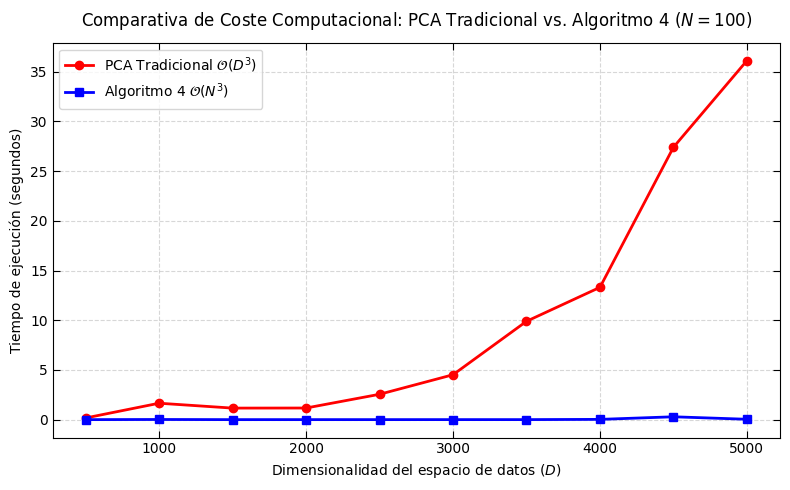

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

N = 100  # Número de muestras (por ejemplo, 100 imágenes)
D_values = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

times_traditional = []
times_dual = []

# Fijamos semilla para repetibilidad
np.random.seed(42)

for D in D_values:
    # Generar matriz sintética de datos centrados de alta dimensionalidad (N x D)
    X = np.random.randn(N, D)

    start_time = time.time()

    # Paso 1: Calcular la matriz S (O(N * D^2))
    S = (1.0 / N) * (X.T @ X)
    # Paso 2: Descomposición espectral de la matriz gigante (O(D^3))
    eigenvalues_S, eigenvectors_S = np.linalg.eigh(S)

    times_traditional.append(time.time() - start_time)

    start_time = time.time()

    # Paso 1: Calcular la matriz dual K (O(D * N^2))
    K = (1.0 / N) * (X @ X.T)
    # Paso 2: Descomposición espectral de la matriz pequeña (O(N^3))
    eigenvalues_K, eigenvectors_K = np.linalg.eigh(K)
    # Paso 3: Reconstrucción y normalización en el espacio original (O(N * D))
    U_raw = X.T @ eigenvectors_K
    eigenvectors_D = U_raw / np.linalg.norm(U_raw, axis=0)

    times_dual.append(time.time() - start_time)

plt.figure(figsize=(8, 5))
plt.plot(D_values, times_traditional, 'o-', color='red', linewidth=2, label='PCA Tradicional $\mathcal{O}(D^3)$')
plt.plot(D_values, times_dual, 's-', color='blue', linewidth=2, label='Algoritmo 4 $\mathcal{O}(N^3)$')

plt.title('Comparativa de Coste Computacional: PCA Tradicional vs. Algoritmo 4 ($N = 100$)', fontsize=12, pad=12)
plt.xlabel('Dimensionalidad del espacio de datos ($D$)', fontsize=10)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper left')

# Ajustes de formato estricto
plt.gca().tick_params(direction='in', top=True, right=True, length=5)
plt.tight_layout()

# Mostrar y guardar imagen para el TFG
plt.savefig('comparativa_coste_pca.png', dpi=300)
plt.savefig("coste_computacional.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("coste_computacional.pdf")

*Figura 7:* Visualización de 15 caras aleatorias del dataset Olivetti Faces.

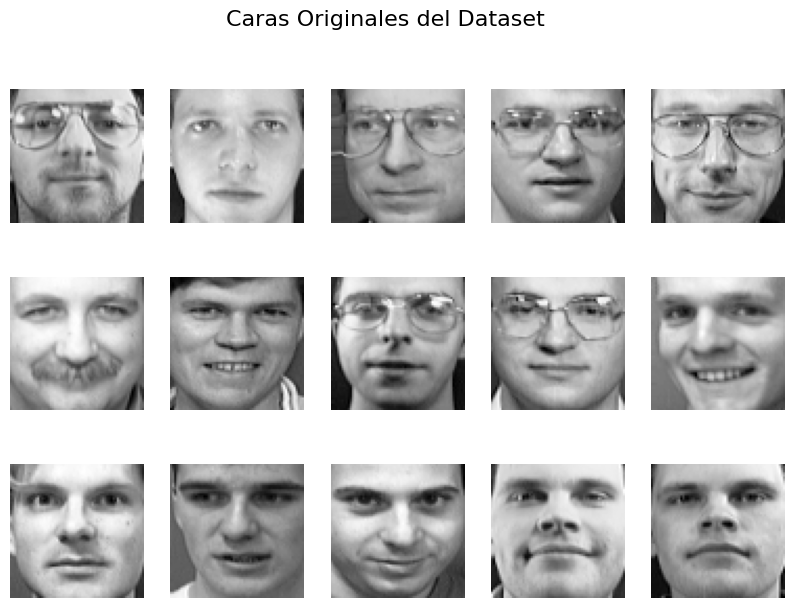

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.io import loadmat

data = loadmat('olivettifaces.mat')
# En el .mat original, las caras suelen venir como (4096, 400)
# Las transponemos para tener (400 imágenes, 4096 píxeles)
X = data['faces'].T
image_shape = (64, 64)

# ==========================================
# 2. VISUALIZACIÓN: CARAS ORIGINALES
# ==========================================
def plot_gallery(title, images, n_col=5, n_row=2, t=True, random=False):
    if random==True:
      idxs = np.random.choice(images.shape[0], size=n_col * n_row, replace=False)
    else:
      idxs = np.arange(n_col*n_row)
    plt.figure(figsize=(2. * n_col, 2.3 * n_row))
    plt.suptitle(title, size=16)
    for i in range(n_col * n_row):
        plt.subplot(n_row, n_col, i + 1)
        # Usamos .T en el reshape porque el dataset .mat viene rotado
        img = images[idxs[i]].reshape(image_shape)
        if t: img = img.T
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.savefig("eigenfaces1.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    files.download("eigenfaces1.pdf")

plot_gallery("Caras Originales del Dataset", X, n_col=5, n_row=3, random = True)

*Figura 8:* Visualización de las 15 primeras componentes principales del dataset Olivetti Faces

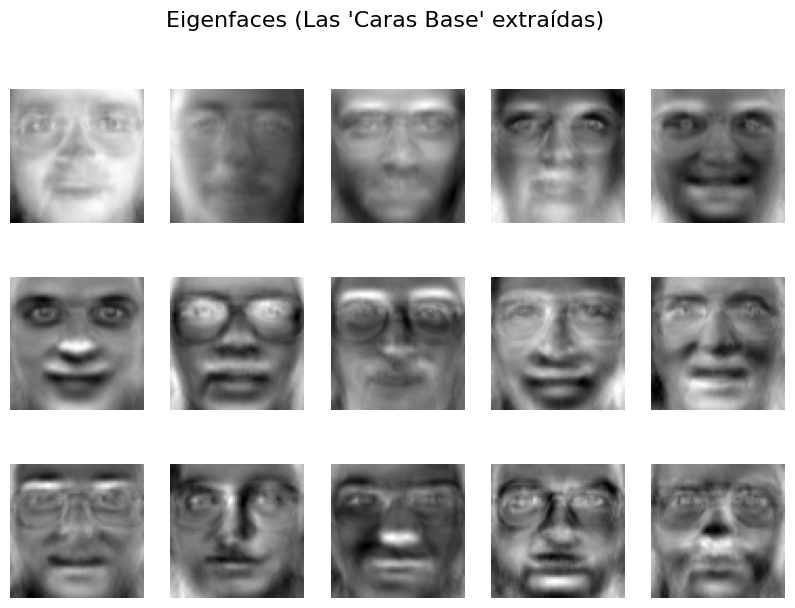

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# 3. PCA Y EIGENFACES (CARAS BASE)
# ==========================================
n_components = 150
pca = PCA(n_components=n_components, whiten=True).fit(X)
eigenfaces = pca.components_

# Mostramos las primeras 10 caras base
plot_gallery("Eigenfaces (Las 'Caras Base' extraídas)", eigenfaces, n_col=5, n_row=3, t=True)

*Figura 9:* Reconstrucción de una cara aleatoria del dataset Olivetti Faces añadiendo en cada paso una componente principal más.

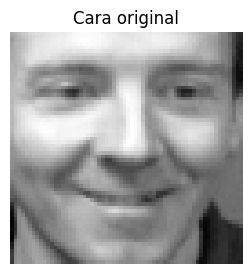

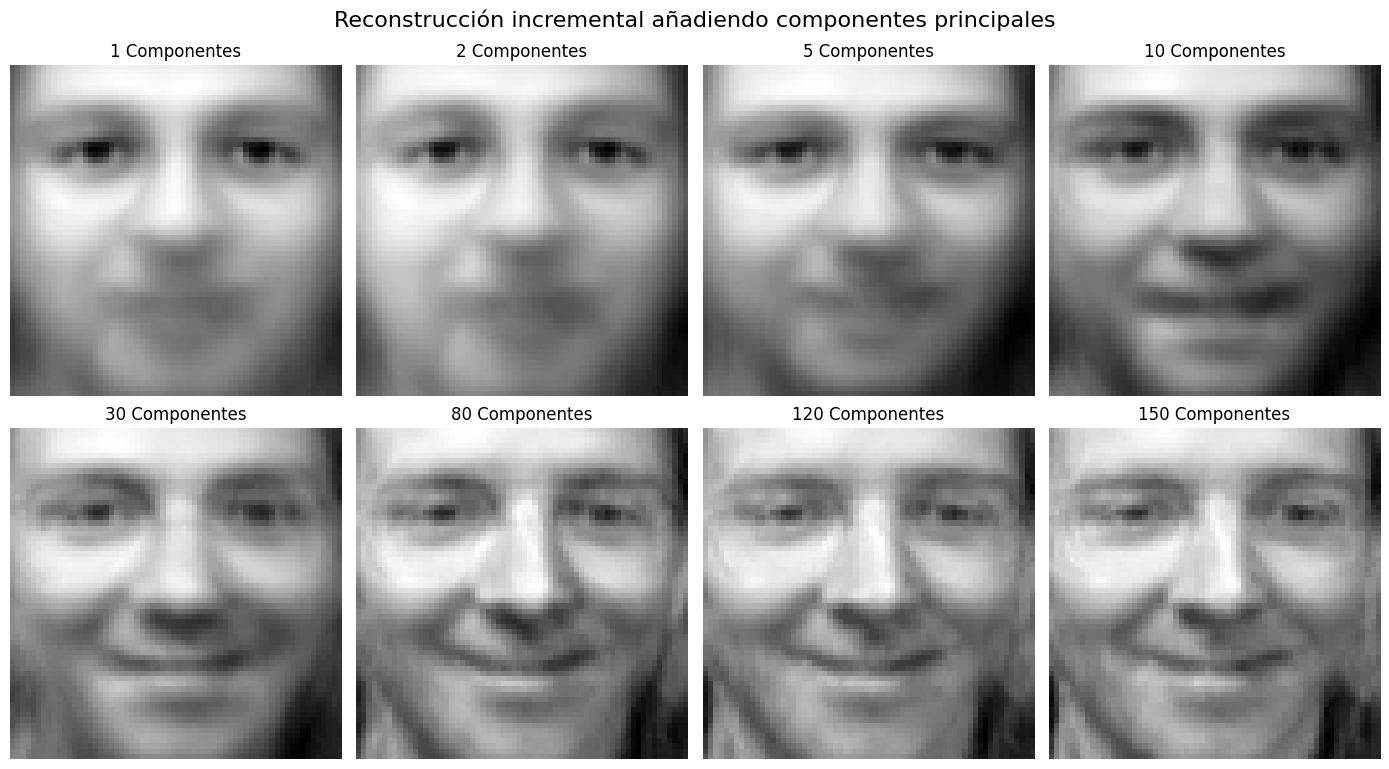

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# 4. RECONSTRUCCIÓN PASO A PASO
# ==========================================
# Elegimos una cara (ej. la número 20)
face_idx = 20
test_face = X[face_idx]

# Niveles de complejidad (Añadido el 120, ahora son 8 elementos)
steps = [1, 2, 5, 10, 30, 80, 120, 150]

# 1. Mostramos la cara original por separado
plt.figure(figsize=(3, 4))
plt.imshow(test_face.reshape(image_shape).T, cmap='gray')
plt.axis('off')
plt.title("Cara original")
plt.show()

# 2. Reconstrucción en cuadrícula de 2 filas x 4 columnas
# Ajustamos el tamaño a (14, 8) para que al tener dos filas se vea alto y claro
plt.figure(figsize=(14, 8))

for i, n in enumerate(steps):
    # Entrenamos un PCA temporal con 'n' componentes
    pca_temp = PCA(n_components=n).fit(X)

    # Proceso: Imagen -> Espacio Reducido -> Imagen Reconstruida
    proyeccion = pca_temp.transform(test_face.reshape(1, -1))
    reconstruccion = pca_temp.inverse_transform(proyeccion)

    # Configuramos la cuadrícula: 2 filas, 4 columnas, posición i + 1
    plt.subplot(2, 4, i + 1)
    plt.imshow(reconstruccion.reshape(image_shape).T, cmap='gray')
    plt.title(f"{n} Componentes", fontsize=12)
    plt.axis('off')

# Título principal del grupo de imágenes
plt.suptitle("Reconstrucción incremental añadiendo componentes principales", size=16, y=0.98)
plt.tight_layout()
plt.savefig("eigenfaces3.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("eigenfaces3.pdf")

*Figura 10:* Comparativa de PPCA vs. PCA.

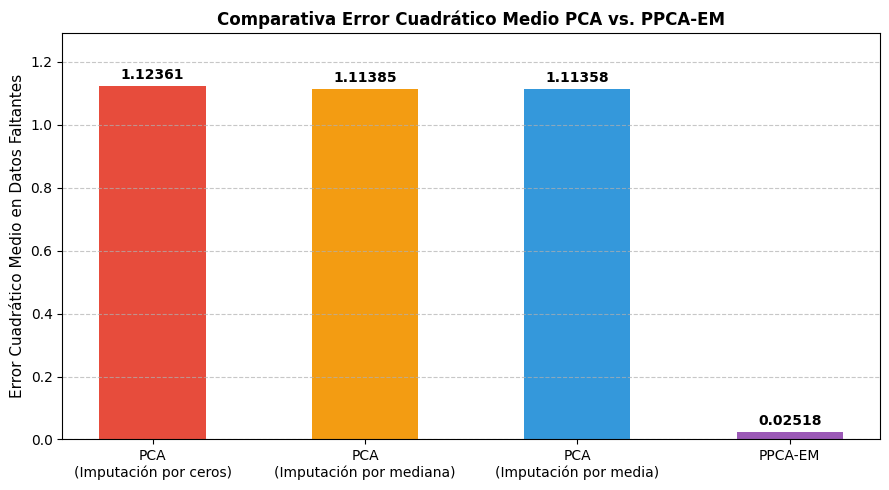

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from google.colab import files

# =============================================================================
# 1. GENERACIÓN DE DATOS (GROUND TRUTH Y MÁSCARA DE FALTANTES)
# =============================================================================
np.random.seed(42)
n_samples = 200
n_features = 15
q_components = 3  # Dimensión latente (q)

# Generamos matriz con estructura lineal latente + ruido gaussiano
Z_true = np.random.randn(n_samples, q_components)
W_true = np.random.randn(n_features, q_components)
X_true = Z_true @ W_true.T + 0.1 * np.random.randn(n_samples, n_features)

# Introducir 30% de NaNs aleatorios (simulando los datos faltantes)
missing_rate = 0.30
mask = np.random.rand(n_samples, n_features) > missing_rate # True = Presente, False = Faltante (rho_ij)
X_missing = X_true.copy()
X_missing[~mask] = np.nan

# =============================================================================
# 2. IMPLEMENTACIÓN FIEL Y ESTRICTA DEL PAPER (PPCA-EM BAJO \sigma^2 -> 0)
# =============================================================================
def ppca_em_paper_exact(X_miss, mask, q, max_iter=150, tol=1e-5):
    n, d = X_miss.shape

    # [Eq. 11] Calcular la media muestral ponderada correctamente según presencia (rho_ij)
    # rho_ij es 1 si está presente, 0 si falta
    rho = mask.astype(float)
    X_zero_filled = np.nan_to_num(X_miss, nan=0.0)

    sum_t = np.sum(X_zero_filled * rho, axis=0)
    sum_rho = np.sum(rho, axis=0)
    mu = sum_t / sum_rho # Media ponderada calculada exactamente como la Eq. 11

    # Centrar los datos observados conocidos [Eq. 10]
    Y_obs = np.zeros_like(X_miss)
    for i in range(n):
        for j in range(d):
            if mask[i, j]:
                Y_obs[i, j] = X_miss[i, j] - mu[j]

    # Inicialización de la matriz de transformación W
    W = np.random.randn(d, q) * 0.1

    # Historial para el cálculo del criterio de convergencia exacto
    e_history = []

    for iteration in range(max_iter):
        W_old = W.copy()

        # Estructuras para almacenar los momentos del Paso E
        E_z = np.zeros((n, q))           # <x_i>
        E_y_full = np.zeros((n, d))      # <y_i> vector compuesto global

        # ---------------------------------------------------------------------
        # PASO E: Simplificado bajo la asunción \sigma^2 -> 0 [Eq. 16 y 17]
        # ---------------------------------------------------------------------
        for i in range(n):
            p_idx = mask[i, :] # Componentes presentes de la observación i

            W_p = W[p_idx, :]   # W_i^(p)
            y_p = Y_obs[i, p_idx] # y_i^(p)

            # [Eq. 16] <x_i> = (W_p^T * W_p)^(-1) * W_p^T * y_p
            # Se añade un término de regularización infinitesimal (1e-9) por estabilidad numérica
            inv_W_p = np.linalg.inv(W_p.T @ W_p + 1e-9 * np.eye(q))
            z_i = inv_W_p @ W_p.T @ y_p
            E_z[i, :] = z_i

            # [Eq. 17] <y_i^(m)> = W_i^(m) * <x_i>
            # Reconstruimos el vector <y_i> completo combinando datos presentes e imputados
            for j in range(d):
                if mask[i, j]:
                    E_y_full[i, j] = Y_obs[i, j] # Si rho_ij >= 1 -> y_i,j^(p)
                else:
                    E_y_full[i, j] = W[j, :] @ z_i # Si rho_ij = 0 -> <y_i,j^(m)>

        # ---------------------------------------------------------------------
        # PASO M: Actualización global simplificada para W
        # ---------------------------------------------------------------------
        # [Eq. 18]: W = [\sum <y_i><x_i>^T] * [\sum <x_i><x_i>^T]^(-1)
        # Nota: Al ser \sigma^2 -> 0, la matriz G_i de la Eq. 15 se colapsa/simplifica
        # directamente en el producto externo del vector <y_i> con <x_i>^T

        sum_yx = np.zeros((d, q))
        sum_xx = np.zeros((q, q))

        for i in range(n):
            z_i = E_z[i, :]
            y_full_i = E_y_full[i, :]

            sum_yx += y_full_i[:, None] @ z_i[None, :] # \sum <y_i><x_i>^T [cite: 69]
            sum_xx += z_i[:, None] @ z_i[None, :]     # \sum <x_i><x_i>^T [cite: 69]

        W = sum_yx @ np.linalg.inv(sum_xx + 1e-9 * np.eye(q)) # [Eq. 18] [cite: 69]

        # ---------------------------------------------------------------------
        # CRITERIO DE CONVERGENCIA: Error cuadrático del modelo [Eq. 20]
        # ---------------------------------------------------------------------
        # e_k = \sum || <y_i> - W*<x_i> ||^2
        e_k = 0.0
        for i in range(n):
            diff = E_y_full[i, :] - W @ E_z[i, :]
            e_k += np.sum(diff ** 2)

        e_history.append(e_k)

        if iteration > 0:
            # \Delta_k = (e_{k-1} - e_k) / e_k
            delta_k = (e_history[-2] - e_history[-1]) / e_history[-1]

            # Salida por convergencia si el cambio normalizado cae por debajo del umbral crítico
            if abs(delta_k) < tol:
                break

    # Reconstrucción final sumando la media original (Des-centrado)
    X_recon = np.zeros_like(X_miss)
    for i in range(n):
        for j in range(d):
            if mask[i, j]:
                X_recon[i, j] = X_miss[i, j]
            else:
                # El valor faltante estimado puro es <y_i^(m)> + mu_j
                X_recon[i, j] = E_y_full[i, j] + mu[j]

    return X_recon

# Ejecutar el algoritmo ajustado estrictamente al Paper
X_recon_ppca_paper = ppca_em_paper_exact(X_missing, mask, q=q_components)

# =============================================================================
# 3. MÉTODOS COMPARATIVOS (LÍNEAS BASE)
# =============================================================================
def baseline_pca_impute(X_miss, q, strategy='mean'):
    X_imputed = X_miss.copy()
    n, d = X_miss.shape
    for j in range(d):
        col_data = X_miss[:, j]
        if strategy == 'mean': val = np.nanmean(col_data)
        elif strategy == 'median': val = np.nanmedian(col_data)
        elif strategy == 'zeros': val = 0.0
        X_imputed[np.isnan(col_data), j] = val

    pca = PCA(n_components=q)
    return pca.inverse_transform(pca.fit_transform(X_imputed))

X_recon_pca_mean = baseline_pca_impute(X_missing, q_components, 'mean')
X_recon_pca_median = baseline_pca_impute(X_missing, q_components, 'median')
X_recon_pca_zeros = baseline_pca_impute(X_missing, q_components, 'zeros')

# =============================================================================
# 4. EVALUACIÓN Y GRÁFICA
# =============================================================================
mse_ppca_paper = mean_squared_error(X_true[~mask], X_recon_ppca_paper[~mask])
mse_pca_mean = mean_squared_error(X_true[~mask], X_recon_pca_mean[~mask])
mse_pca_median = mean_squared_error(X_true[~mask], X_recon_pca_median[~mask])
mse_pca_zeros = mean_squared_error(X_true[~mask], X_recon_pca_zeros[~mask])

methods = ['PCA\n(Imputación por ceros)', 'PCA\n(Imputación por mediana)', 'PCA\n(Imputación por media)', 'PPCA-EM']
mse_values = [mse_pca_zeros, mse_pca_median, mse_pca_mean, mse_ppca_paper]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, mse_values, color=['#e74c3c', '#f39c12', '#3498db', '#9b59b6'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(mse_values)*0.01), f'{yval:.5f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparativa Error Cuadrático Medio PCA vs. PPCA-EM', fontsize=12, fontweight='bold')
plt.ylabel('Error Cuadrático Medio en Datos Faltantes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(mse_values) * 1.15)
plt.tight_layout()
plt.savefig("EM.pdf", format="pdf", bbox_inches="tight")
plt.show()

files.download("EM.pdf")

*Figura 11:* Gráfico scree-plot aplicado al mismo conjunto de datos de la Figura 10.

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7789/3758798516.py:21: SyntaxWarning: invalid escape sequence '\l'
  label='Autovalores ($\lambda_i$)')
/tmp/ipykernel_7789/3758798516.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(componentes, autovalores_ordenados, 'ro-', color='#2c3e50',


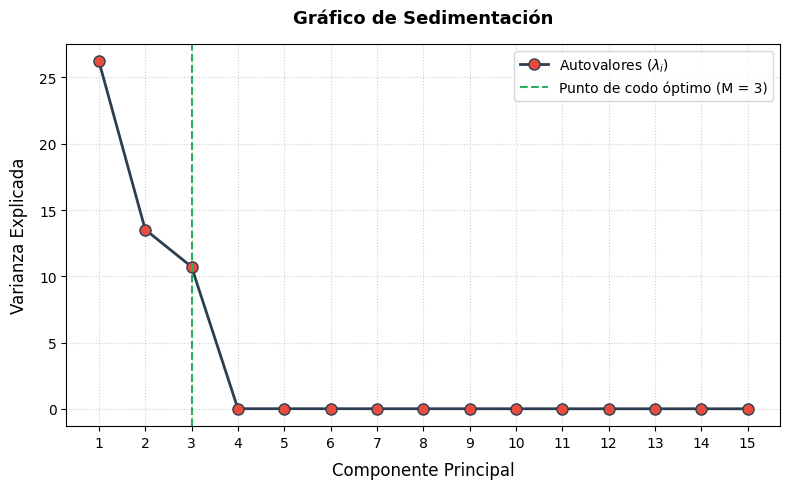

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
X_centered = X_true - np.mean(X_true, axis=0)

# =============================================================================
# 2. CÁLCULO DE AUTOVALORES (Espectro de la matriz de covarianza)
# =============================================================================
cov_matrix = np.cov(X_centered, rowvar=False)
autovalores, _ = np.linalg.eig(cov_matrix)

# Ordenar los autovalores de mayor a menor
autovalores_ordenados = np.sort(autovalores)[::-1]
componentes = np.arange(1, n_features + 1)

# =============================================================================
# 3. GENERACIÓN DEL GRÁFICO DE SEDIMENTACIÓN (SCREE PLOT)
# =============================================================================
plt.figure(figsize=(8, 5))

# Dibujar la línea y los puntos de los autovalores
plt.plot(componentes, autovalores_ordenados, 'ro-', color='#2c3e50',
         linewidth=2, markersize=8, markerfacecolor='#e74c3c', markeredgecolor='#2c3e50',
         label='Autovalores ($\lambda_i$)')

# Dibujar línea discontinua vertical para marcar el "codo" óptimo en M=3
plt.axvline(x=q_components, color='#27ae60', linestyle='--', linewidth=1.5,
            label=f'Punto de codo óptimo (M = {q_components})')

# Personalización estética del gráfico (Estilo Académico Formal)
plt.title('Gráfico de Sedimentación', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Componente Principal', fontsize=12, labelpad=8)
plt.ylabel('Varianza Explicada', fontsize=12, labelpad=8)

plt.xticks(componentes) # Forzar a que se muestren todos los números del 1 al 15
plt.grid(axis='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=False)

# Ajustar márgenes
plt.tight_layout()

# Guardar la gráfica en formato vectorial PDF para tu documento LaTeX/Word
# (Esto garantiza que nunca se pixele al hacer zoom en la memoria)
plt.savefig("grafica_scree_plot.pdf", format="pdf", bbox_inches="tight")

# Mostrar la gráfica en pantalla
plt.show()
files.download("grafica_scree_plot.pdf")